In [1]:
import pandas as pd
import torch
from torch_geometric.data import HeteroData

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 4551] An Application Control policy has blocked this file
  import torch_geometric.typing
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)

2.2.2+cu121
2.7.0


In [3]:
drug_protein = pd.read_csv("../data/interim/drug_protein_edges.csv")
protein_protein = pd.read_csv("../data/interim/protein_protein_edges.csv")
protein_disease = pd.read_csv("../data/interim/protein_disease_edges.csv")

print("Drug-Protein edges:", len(drug_protein))
print("Protein-Protein edges:", len(protein_protein))
print("Protein-Disease edges:", len(protein_disease))

Drug-Protein edges: 26766
Protein-Protein edges: 472588
Protein-Disease edges: 38959


In [4]:
# Unique drugs
drugs = drug_protein["drug_id"].unique()

# Unique proteins (3 sources se)
proteins = pd.concat([
    drug_protein["protein_id"],
    protein_protein["protein1"],
    protein_protein["protein2"],
    protein_disease["protein"]
]).unique()

# Unique diseases
diseases = protein_disease["disease"].unique()

print("Unique drugs:", len(drugs))
print("Unique proteins:", len(proteins))
print("Unique diseases:", len(diseases))

Unique drugs: 9875
Unique proteins: 19425
Unique diseases: 7687


In [5]:
drug_map = {drug: idx for idx, drug in enumerate(drugs)}
protein_map = {protein: idx for idx, protein in enumerate(proteins)}
disease_map = {disease: idx for idx, disease in enumerate(diseases)}

print("Drug map size:", len(drug_map))
print("Protein map size:", len(protein_map))
print("Disease map size:", len(disease_map))

Drug map size: 9875
Protein map size: 19425
Disease map size: 7687


In [6]:
# Drug → Protein edges

dp_src = drug_protein["drug_id"].map(drug_map).values
dp_dst = drug_protein["protein_id"].map(protein_map).values

dp_edge_index = torch.tensor([dp_src, dp_dst], dtype=torch.long)

print("Drug-Protein edge_index shape:", dp_edge_index.shape)


Drug-Protein edge_index shape: torch.Size([2, 26766])


C:\Users\Srija Paul Chowdhury\AppData\Local\Temp\ipykernel_28260\555995350.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:278.)
  dp_edge_index = torch.tensor([dp_src, dp_dst], dtype=torch.long)


In [7]:
# Protein → Protein edges (STRING)

ppi_src = protein_protein["protein1"].map(protein_map).values
ppi_dst = protein_protein["protein2"].map(protein_map).values

ppi_edge_index = torch.tensor([ppi_src, ppi_dst], dtype=torch.long)

print("Protein-Protein edge_index shape:", ppi_edge_index.shape)

Protein-Protein edge_index shape: torch.Size([2, 472588])


In [8]:
# Protein → Disease edges

pd_src = protein_disease["protein"].map(protein_map).values
pd_dst = protein_disease["disease"].map(disease_map).values

pd_edge_index = torch.tensor([pd_src, pd_dst], dtype=torch.long)

print("Protein-Disease edge_index shape:", pd_edge_index.shape)

Protein-Disease edge_index shape: torch.Size([2, 38959])


In [9]:
data = HeteroData()

# Node counts
data["drug"].num_nodes = len(drugs)
data["protein"].num_nodes = len(proteins)
data["disease"].num_nodes = len(diseases)

# Edge relations
data["drug", "targets", "protein"].edge_index = dp_edge_index
data["protein", "interacts", "protein"].edge_index = ppi_edge_index
data["protein", "associated_with", "disease"].edge_index = pd_edge_index

data

HeteroData(
  drug={ num_nodes=9875 },
  protein={ num_nodes=19425 },
  disease={ num_nodes=7687 },
  (drug, targets, protein)={ edge_index=[2, 26766] },
  (protein, interacts, protein)={ edge_index=[2, 472588] },
  (protein, associated_with, disease)={ edge_index=[2, 38959] }
)

In [18]:
# Save the heterograph

torch.save(data, "../data/processed/hetero_graph.pt")

print("Heterogeneous graph saved successfully.")

Heterogeneous graph saved successfully.


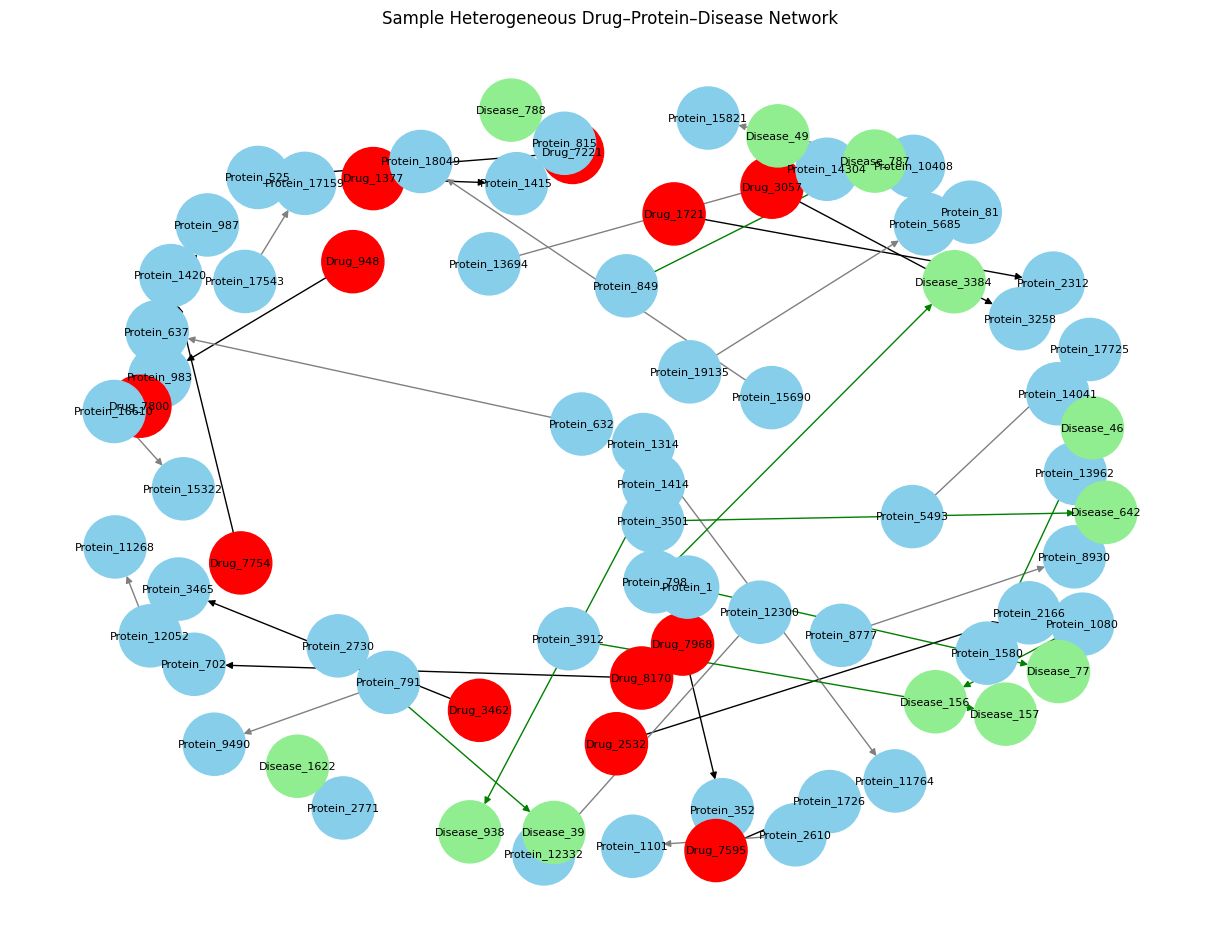

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
import random

G = nx.DiGraph()

# sample edges
num_dp = 12
num_pd = 12
num_pp = 15

dp_indices = random.sample(range(dp_edge_index.shape[1]), num_dp)
pd_indices = random.sample(range(pd_edge_index.shape[1]), num_pd)
pp_indices = random.sample(range(ppi_edge_index.shape[1]), num_pp)

# Drug → Protein edges
for i in dp_indices:
    src = dp_edge_index[0][i].item()
    dst = dp_edge_index[1][i].item()
    G.add_edge(f"Drug_{src}", f"Protein_{dst}", type="dp")

# Protein ↔ Protein edges
for i in pp_indices:
    src = ppi_edge_index[0][i].item()
    dst = ppi_edge_index[1][i].item()
    G.add_edge(f"Protein_{src}", f"Protein_{dst}", type="pp")

# Protein → Disease edges
for i in pd_indices:
    src = pd_edge_index[0][i].item()
    dst = pd_edge_index[1][i].item()
    G.add_edge(f"Protein_{src}", f"Disease_{dst}", type="pd")

# Node colors
node_colors = []
for node in G.nodes():
    if node.startswith("Drug"):
        node_colors.append("red")
    elif node.startswith("Protein"):
        node_colors.append("skyblue")
    else:
        node_colors.append("lightgreen")

# Edge colors by relation
edge_colors = []
for u,v,data in G.edges(data=True):
    if data["type"] == "dp":
        edge_colors.append("black")
    elif data["type"] == "pp":
        edge_colors.append("gray")
    else:
        edge_colors.append("green")

plt.figure(figsize=(12,9))

pos = nx.spring_layout(G, k=0.6, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    node_size=2000,
    font_size=8
)

plt.title("Sample Heterogeneous Network")
plt.show()

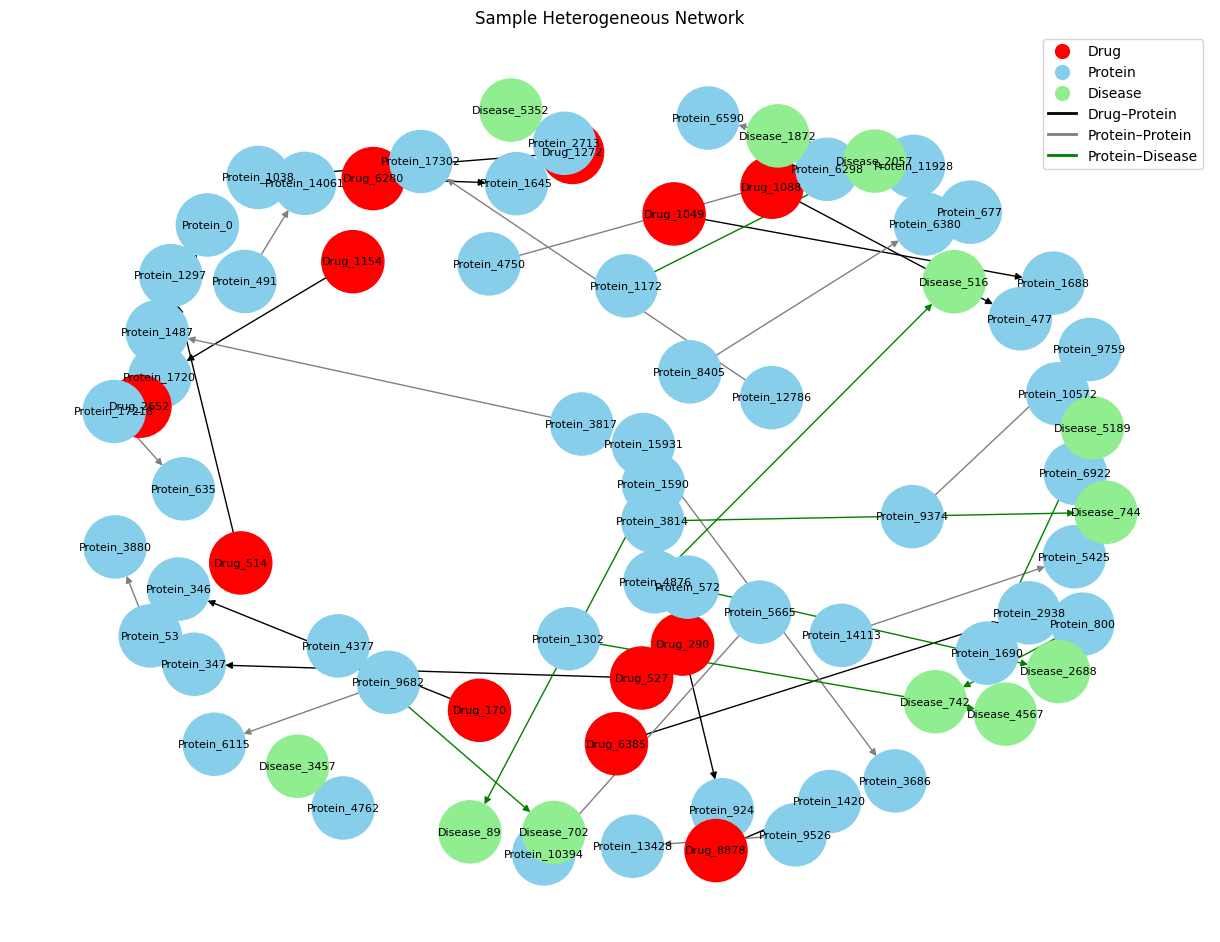

In [22]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from matplotlib.lines import Line2D

G = nx.DiGraph()

num_dp = 12
num_pd = 12
num_pp = 15

dp_indices = random.sample(range(dp_edge_index.shape[1]), num_dp)
pd_indices = random.sample(range(pd_edge_index.shape[1]), num_pd)
pp_indices = random.sample(range(ppi_edge_index.shape[1]), num_pp)

# Drug → Protein
for i in dp_indices:
    src = dp_edge_index[0][i].item()
    dst = dp_edge_index[1][i].item()
    G.add_edge(f"Drug_{src}", f"Protein_{dst}", type="dp")

# Protein ↔ Protein
for i in pp_indices:
    src = ppi_edge_index[0][i].item()
    dst = ppi_edge_index[1][i].item()
    G.add_edge(f"Protein_{src}", f"Protein_{dst}", type="pp")

# Protein → Disease
for i in pd_indices:
    src = pd_edge_index[0][i].item()
    dst = pd_edge_index[1][i].item()
    G.add_edge(f"Protein_{src}", f"Disease_{dst}", type="pd")

# Node colors
node_colors = []
for node in G.nodes():
    if node.startswith("Drug"):
        node_colors.append("red")
    elif node.startswith("Protein"):
        node_colors.append("skyblue")
    else:
        node_colors.append("lightgreen")

# Edge colors
edge_colors = []
for u,v,data in G.edges(data=True):
    if data["type"] == "dp":
        edge_colors.append("black")
    elif data["type"] == "pp":
        edge_colors.append("gray")
    else:
        edge_colors.append("green")

plt.figure(figsize=(12,9))
pos = nx.spring_layout(G, seed=42, k=0.6)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    node_size=2000,
    font_size=8
)

# Legend
legend_elements = [
    Line2D([0],[0], marker='o', color='w', label='Drug', markerfacecolor='red', markersize=12),
    Line2D([0],[0], marker='o', color='w', label='Protein', markerfacecolor='skyblue', markersize=12),
    Line2D([0],[0], marker='o', color='w', label='Disease', markerfacecolor='lightgreen', markersize=12),
    Line2D([0],[0], color='black', lw=2, label='Drug–Protein'),
    Line2D([0],[0], color='gray', lw=2, label='Protein–Protein'),
    Line2D([0],[0], color='green', lw=2, label='Protein–Disease')
]

plt.legend(handles=legend_elements, loc='best')

plt.title("Sample Heterogeneous Network")
plt.show()